# 02b · Segmentation from fluorescence

For samples with inclusion bodies (IBs) but no usable brightfield stack, and
for the images notebook 02a rejected:

1. **IBs** from the fluorescence intensity image (difference of Gaussians
   and Otsu threshold);
2. **cells** from the same image with Cellpose-SAM, after clipping the IBs;
3. **cytosol** = cells minus the IBs and a halo around them.

Masks are written to `masks_auto/<sample>_ib_masks/` and
`masks_auto/<sample>_cell_masks/`, with one overview `.png` per sample.

In [5]:
import os

import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.segmentation import expand_labels

from cellpose import models

import flim_fret_data_processing.config as config
from flim_fret_data_processing.helpers import (
    index_samples,
    keep_solid_pieces,
    overlay_labels,
    save_labels,
    save_overview,
    segment_ibs,
)

## Inputs

In [6]:
raw_dir       = config.RAW_DIR          # only to find the session of each sample
intensity_dir = config.INTENSITY_DIR    # <session>/<sample>_export
output_dir    = config.MASKS_AUTO_DIR

# Sample folders to segment.
samples = ['665', '1259', '1856', 'bol', 'sod',
           'R2F-1', 'R2F-2', 'R2N-1', 'R2N-3', 'R3F-2', 'R3F-4',
           '6']

# Leave images alone that already have masks, e.g. from notebook 02a.
only_missing = True

# --- inclusion bodies ---
ib_dog_sigma_small = 1     # px; suppresses shot noise, keep well below the IB radius
ib_dog_sigma_large = 3     # px; background scale, raise to keep large IBs whole
ib_min_size        = 10    # px; smallest accepted IB
ib_expand_distance = 1.8   # px the saved IB label is grown by, to cover its edge pixels
ib_halo_distance   = 7     # px around each IB excluded from the cytosol mask and
                           # from the image statistics below

# --- cells (Cellpose-SAM on the clipped fluorescence image) ---
ib_clip_percentile  = 99.5          # the image is capped at this percentile of the non-halo pixels
cellpose_percentile = (1.0, 99.5)   # percentiles of the non-halo pixels used for normalisation
cellpose_flow_threshold     = 0.4
cellpose_cellprob_threshold = 0.0
use_gpu = __import__("torch").cuda.is_available()

# --- cytosol: pieces smaller or thinner than this are dropped ---
cell_min_area           = 5   # px
cell_min_half_thickness = 1   # px

## Load the intensity images

In [7]:
sample_index = index_samples(raw_dir)

images = []   # (sample, image base name, fluorescence image)
for sample in samples:
    export_dir = os.path.join(intensity_dir, sample_index[sample]['session'], sample + '_export')
    for f in sorted(f for f in os.listdir(export_dir) if f.endswith('.tif')):
        base = f[:-len('.tif')]
        done = os.path.exists(os.path.join(output_dir, sample + '_ib_masks',
                                           base + '_ib_labels.tif'))
        if only_missing and done:
            continue
        images.append((sample, base, io.imread(os.path.join(export_dir, f), as_gray=True)))

print(f"{len(images)} image(s) to segment from {len(samples)} sample(s)")

105 image(s) to segment from 12 sample(s)


## Segment

The IBs are 10-30 times brighter than the cytosol and would dominate both
the normalisation and the segmentation. Before Cellpose sees the image, it is
therefore capped at `ib_clip_percentile` of the pixels outside the IB halos,
and the contrast range is taken from those pixels as well.

The IB halo keeps out-of-focus IB fluorescence out of the cytosol mask.
Cutting it out leaves fragments, which `keep_solid_pieces` removes.

In [9]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Sparse invariant checks are implicitly disabled.*",
    category=UserWarning,
)

model = models.CellposeModel(gpu=use_gpu)

overview = {}   # sample -> rows of the overview figure

for sample, base, image in images:
    ib_labels = segment_ibs(image, ib_dog_sigma_small, ib_dog_sigma_large,
                            ib_min_size, ib_expand_distance)
    ib_halo = expand_labels(ib_labels, distance=ib_halo_distance) > 0

    outside = image[~ib_halo]
    clipped = np.clip(image, None, np.percentile(outside, ib_clip_percentile))
    low, high = np.percentile(outside, cellpose_percentile)
    cell_labels, _, _ = model.eval(
        clipped,
        flow_threshold=cellpose_flow_threshold,
        cellprob_threshold=cellpose_cellprob_threshold,
        normalize={'lowhigh': (float(low), float(high))},
    )

    cytosol_labels = cell_labels.copy()
    cytosol_labels[ib_halo] = 0
    cytosol_labels, n_dropped = keep_solid_pieces(cytosol_labels, cell_min_area,
                                                  cell_min_half_thickness)

    print(f"{sample}/{base}: {ib_labels.max()} IB(s), {cytosol_labels.max()} cytosol mask(s), "
          f"{n_dropped} fragment(s) dropped")

    save_labels(os.path.join(output_dir, sample + '_ib_masks'),
                base + '_ib_labels.tif', ib_labels)
    save_labels(os.path.join(output_dir, sample + '_cell_masks'),
                base + '_cytosol_labels.tif', cytosol_labels)

    overview.setdefault(sample, []).append((
        base,
        overlay_labels(image, ib_labels, alpha=0.5),
        overlay_labels(image, cytosol_labels, alpha=0.5),
    ))

for sample, rows in overview.items():
    save_overview(os.path.join(output_dir, sample + '_overview.png'), sample, rows,
                  ("IB labels", "Cytosol labels"))

665/MultiHarp150_2025-03-13_12-27-12: 3 IB(s), 1 cytosol mask(s), 9 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-29-15: 4 IB(s), 4 cytosol mask(s), 5 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-30-45: 4 IB(s), 3 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-32-02: 3 IB(s), 1 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-33-27: 3 IB(s), 0 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-35-06: 2 IB(s), 1 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-37-01: 4 IB(s), 0 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-39-19: 2 IB(s), 0 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-44-02: 2 IB(s), 4 cytosol mask(s), 5 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-46-57: 3 IB(s), 0 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-48-32: 2 IB(s), 1 cytosol mask(s), 0 fragment(s) dropped
665/MultiHarp150_2025-03-13_12-4

## Example

The overlays of the last sample; all samples are in the saved overviews.

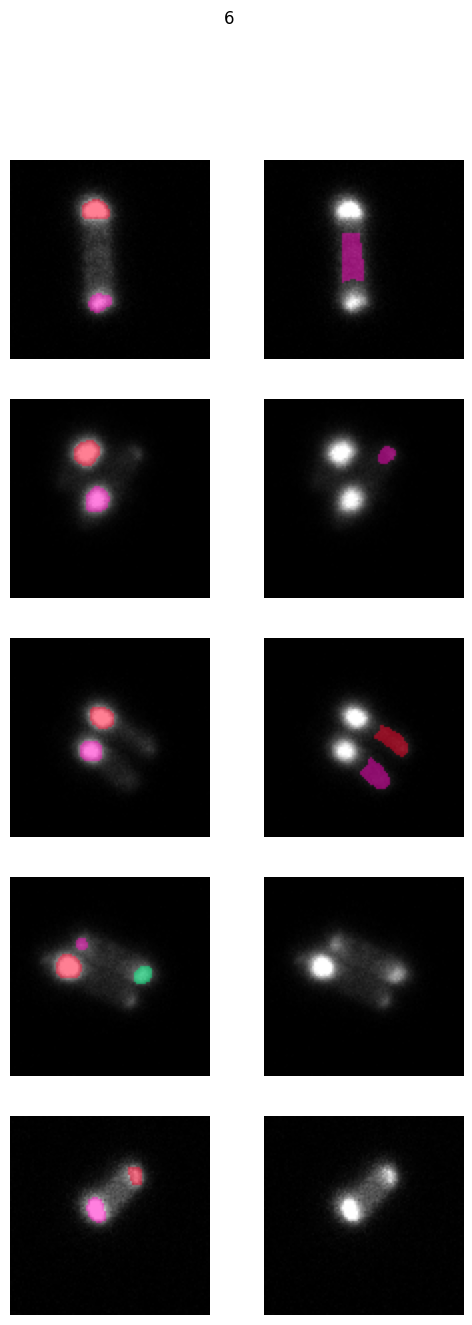

In [10]:
if overview:
    sample, rows = list(overview.items())[-1]
    fig, axes = plt.subplots(len(rows), 2, figsize=(6, 3 * len(rows)), squeeze=False)
    for row_axes, (base, *overlays) in zip(axes, rows):
        for ax, overlay in zip(row_axes, overlays):
            ax.imshow(overlay)
            ax.set_axis_off()
    fig.suptitle(sample)
    plt.show()